In [2]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_val_score
)

import sys
import os

sys.path.append(
    os.path.abspath("..")
)

from src.evaluate import rmse_cv

In [3]:
X_train = pd.read_csv(
    "../data/X_train_tree.csv"
)

X_test = pd.read_csv(
    "../data/X_test_tree.csv"
)

y_train = pd.read_csv(
    "../data/y_train.csv"
).squeeze()

test = pd.read_csv(
    "../data/test.csv"
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(1455, 304)
(1459, 304)
(1455,)


In [4]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_rmse = rmse_cv(
    xgb_model,
    X_train,
    y_train
).mean()

print(
    f"XGBoost RMSE: {xgb_rmse:.5f}"
)

XGBoost RMSE: 0.11952


In [5]:
xgb_model_v2 = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_rmse_v2 = rmse_cv(
    xgb_model_v2,
    X_train,
    y_train
).mean()

print(
    f"XGB v2 RMSE: {xgb_rmse_v2:.5f}"
)

XGB v2 RMSE: 0.11211


In [6]:
xgb_model_v2.fit(
    X_train,
    y_train
)

print("XGB v2 訓練完成")

XGB v2 訓練完成


In [7]:
xgb_pred_log_v2 = xgb_model_v2.predict(
    X_test
)

xgb_pred_v2 = np.expm1(
    xgb_pred_log_v2
)

print(xgb_pred_v2[:5])

[126565.45 161493.23 177219.97 194290.8  186604.88]


In [8]:
submission_v2 = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": xgb_pred_v2
})

submission_v2.to_csv(
    "../submissions/xgb_v2_submission.csv",
    index=False
)

print("XGB v2 Submission 已建立")

XGB v2 Submission 已建立


XGB 調校後 RMSE: 0.11167
XGB Random Search Submission 已建立



C:\Users\Wayne.Chang\AppData\Local\Temp\ipykernel_24356\1096533800.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


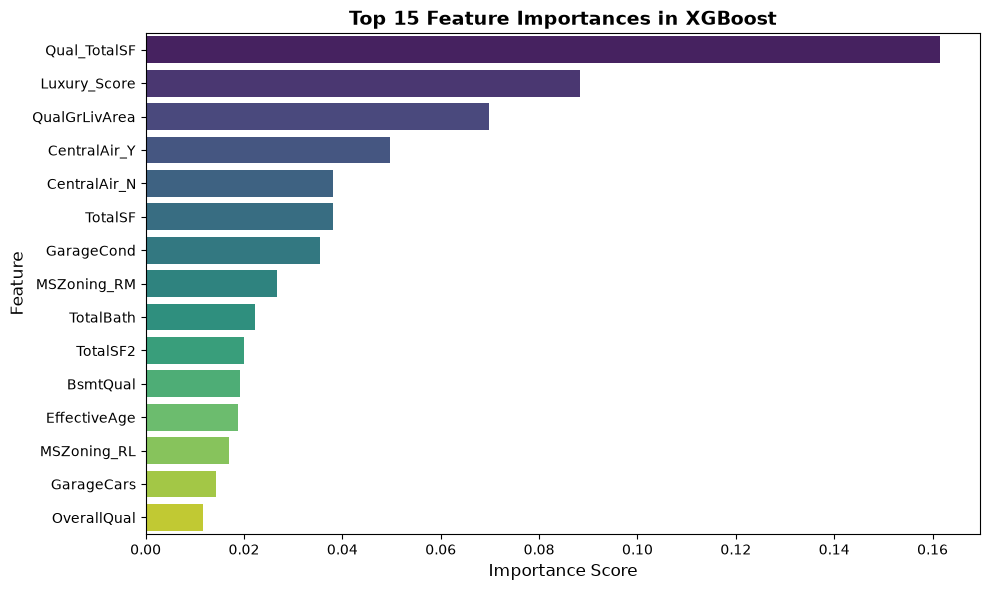

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

xgb_best = XGBRegressor(
    n_estimators=3500,    
    learning_rate=0.015,
    max_depth=3,            
    subsample=0.8,          # 提高取樣率，讓它看清楚資料
    colsample_bytree=0.7,   # 讓它每次建樹能看到 70% 的特徵，重新找回特徵間的關聯
    min_child_weight=2,     # 降低分葉門檻，讓它能捕捉更細微的房價波動
    gamma=0.01,             # 放寬分裂限制
    reg_alpha=0.01,         
    reg_lambda=1.5,         
    random_state=42
)

# 訓練並預測
xgb_best.fit(X_train, y_train)
xgb_best_pred_log = xgb_best.predict(X_test)
xgb_best_pred = np.expm1(xgb_best_pred_log)

# 輸出 submission
submission_best = pd.DataFrame({"Id": test["Id"], "SalePrice": xgb_best_pred})
submission_best.to_csv("../submissions/xgb_random_search_submission.csv", index=False)

# 4. 評估 RMSE
xgb_best_rmse = rmse_cv(xgb_best, X_train, y_train).mean()
print(f"XGB 調校後 RMSE: {xgb_best_rmse:.5f}")
print("XGB Random Search Submission 已建立\n")

# ==========================================
# 5. 繪製特徵重要性 (Feature Importance)
# ==========================================
# 提取特徵重要性並排序
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 設定畫布並繪製前 15 名最重要的特徵
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importances.head(15), 
    palette='viridis'
)
plt.title('Top 15 Feature Importances in XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
print(feature_importances.head(30))

                   Feature  Importance
46            Qual_TotalSF    0.161567
70            Luxury_Score    0.088392
52           QualGrLivArea    0.069883
244           CentralAir_Y    0.049751
243           CentralAir_N    0.038176
41                 TotalSF    0.038099
33              GarageCond    0.035550
92             MSZoning_RM    0.026651
45               TotalBath    0.022175
53                TotalSF2    0.019959
7                 BsmtQual    0.019221
44            EffectiveAge    0.018875
91             MSZoning_RL    0.017036
30              GarageCars    0.014234
2              OverallQual    0.011613
61       Neighborhood_Rank    0.011600
49            OverallScore    0.011536
50             GarageScore    0.011087
51        TotalHomeQuality    0.010383
32              GarageQual    0.010040
121    Neighborhood_IDOTRR    0.008774
270           PavedDrive_N    0.008517
69       Garage_Real_Value    0.008203
68    Fireplace_Real_Value    0.007723
28             FireplaceQ